In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
307,15733973,Female,47,113000,1
333,15587177,Male,40,65000,0
343,15629739,Female,47,51000,1
26,15792818,Male,49,28000,1
395,15691863,Female,46,41000,1


In [4]:
df.drop(columns=['User ID' , 'Gender'] , inplace=True)

In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
194,28,89000,0
188,35,72000,0
178,24,23000,0
232,40,107000,1
271,59,76000,1


In [7]:
df['Age'].describe()

count    400.000000
mean      37.655000
std       10.482877
min       18.000000
25%       29.750000
50%       37.000000
75%       46.000000
max       60.000000
Name: Age, dtype: float64

In [8]:
df['EstimatedSalary'].describe()

count       400.000000
mean      69742.500000
std       34096.960282
min       15000.000000
25%       43000.000000
50%       70000.000000
75%       88000.000000
max      150000.000000
Name: EstimatedSalary, dtype: float64

In [9]:
import seaborn as sns

<Axes: >

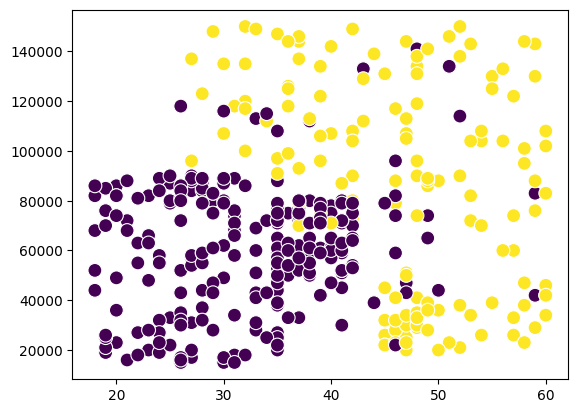

In [14]:
sns.scatterplot(x = df.iloc[ : , 0].values , y = df.iloc[ : , 1].values , c = df.iloc[ : , 2].values , s = 100)

In [16]:
X = df.iloc[: , 0 : 2]
y = df.iloc[: , -1]

In [ ]:
# X = df.drop(columns=['Age' , 'EstimatedSalary'])
# y = df['Purchased']

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [19]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

2025-12-22 06:26:03.055090: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-22 06:26:03.090034: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766384763.112134    4531 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766384763.119625    4531 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766384763.149118    4531 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [20]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/home/subhamoy/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1766384770.032878    4531 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4837 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


In [21]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [22]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100


I0000 00:00:1766384803.266519    5065 service.cc:152] XLA service 0x783958003840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766384803.266560    5065 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-12-22 06:26:43.294644: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1766384803.401867    5065 cuda_dnn.cc:529] Loaded cuDNN version 91301


 1/10 ━━━━━━━━━━━━━━━━━━━━ 8s 916ms/step - accuracy: 0.6250 - loss: 472.9641

I0000 00:00:1766384803.650133    5065 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5094 - loss: 322.8096 - val_accuracy: 0.6000 - val_loss: 282.2532
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5344 - loss: 112.6040 - val_accuracy: 0.6000 - val_loss: 24.9328
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5188 - loss: 74.3921 - val_accuracy: 0.4000 - val_loss: 22.4063
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5094 - loss: 39.3580 - val_accuracy: 0.4000 - val_loss: 120.5920
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4781 - loss: 99.1836 - val_accuracy: 0.4000 - val_loss: 47.8990
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4938 - loss: 53.8804 - val_accuracy: 0.6000 - val_loss: 58.6542
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5344 - loss: 32.7015 - val_accuracy: 0.6000 - val_loss: 97.6686
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5562 - loss: 33.5021 - val_accuracy: 0.

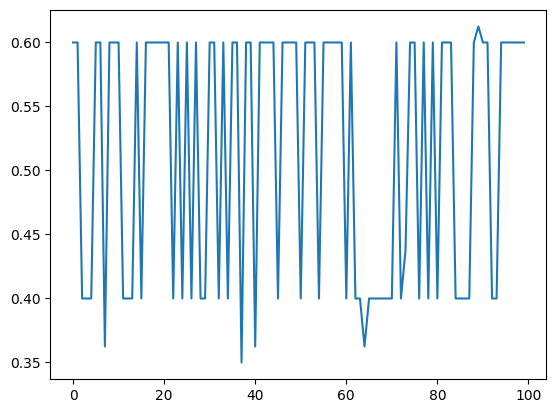

In [23]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

## Apply Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)

In [27]:
X_test_scaled = scaler.transform(X_test)

In [28]:
X_test_scaled

array([[-0.84826272,  0.40218125],
       [-1.62050759, -1.57325199],
       [-0.07601785, -0.48234109],
       [-0.84826272,  0.16630863],
       [ 1.56500249,  0.01888824],
       [ 0.88928823, -1.45531567],
       [-1.42744637,  0.37269718],
       [-0.94479333, -1.10150673],
       [ 0.21357397, -0.27595254],
       [-0.17254846,  1.66999662],
       [-1.33091576, -1.36686344],
       [-1.52397698, -1.24892713],
       [-0.5586709 ,  1.40463991],
       [ 0.69622701,  0.28424494],
       [-0.26907907, -0.30543662],
       [-0.46214029, -0.77718187],
       [-1.8135688 ,  0.01888824],
       [ 2.14418614, -0.80666595],
       [ 1.46847188,  0.07785639],
       [-1.13785454, -0.77718187],
       [-0.07601785,  0.25476086],
       [ 0.69622701, -0.71821372],
       [-0.75173211, -0.21698439],
       [-0.17254846, -1.07202266],
       [-1.23438515,  0.31372902],
       [ 0.69622701, -1.10150673],
       [ 0.69622701, -1.39634752],
       [ 0.21357397, -0.36440478],
       [ 0.5996964 ,

<Axes: >

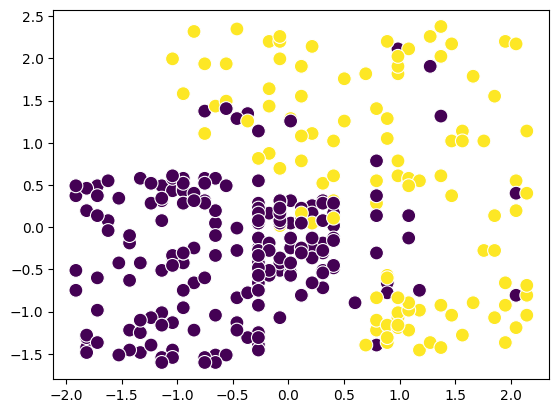

In [31]:
sns.scatterplot(x = X_train_scaled[:,0],y = X_train_scaled[:,1] , c = y_train , s = 100)

In [32]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100


/home/subhamoy/miniforge3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5594 - loss: 0.7152 - val_accuracy: 0.6000 - val_loss: 0.6860
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6687 - loss: 0.6549 - val_accuracy: 0.6875 - val_loss: 0.6260
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7563 - loss: 0.6033 - val_accuracy: 0.7500 - val_loss: 0.5753
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7937 - loss: 0.5615 - val_accuracy: 0.7625 - val_loss: 0.5318
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8000 - loss: 0.5237 - val_accuracy: 0.7750 - val_loss: 0.4937
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8125 - loss: 0.4899 - val_accuracy: 0.7750 - val_loss: 0.4617
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8250 - loss: 0.4602 - val_accuracy: 0.7875 - val_loss: 0.4339
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8375 - loss: 0.4336 - val_accuracy: 0.8125 - val_loss: 0.

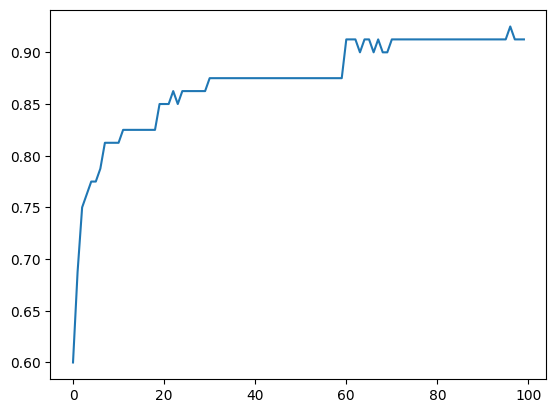

In [33]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])